In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
import os
from pathlib import Path
import time
import copy
from IPython.display import clear_output
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import skimage
from skimage.registration import phase_cross_correlation

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

from importlib import reload

import ray

import esc_fresnel

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics


/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-04-01 14:20:08,523	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
wfe_dir = 'V20250325-cropped'
wfe_dir = 'V20250326-cropped'

dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat.fits')
dh_command = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-8.fits')
dh_command = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-9.fits')
dh_command = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_6e-10.fits')

wfe_keys = [
    'm1',
    'm2',
    'm3', 
    'm4',
    'oap1',
    'fm1',
    'oap2',
    'oap3',
    'fsm',
    'fm2',
    'oap4',
    'oap5',
    'input_lp',
    'input_qwp',
    'oap6',
    'oap7',
    'oap9',
    'collimator',
    'filter',
    'output_qwp',
    'output_lp',
    'oap10',
]

wfes = {}
for optic in wfe_keys:
    wfe = poppy.FITSOpticalElement(
        opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_opd.fits'), 
        opdunits='nanometers',
        transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_amp.fits'),
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

# dm_map = poppy.FITSOpticalElement(
#     opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat.fits'), 
#     opdunits='meters',
#     name=f'dm_wfe',
#     pixelscale='SCALE',
#     planetype=poppy.poppy_core.PlaneType.intermediate,
# )
# dm_map.opd *= 2

dm_map = poppy.FITSOpticalElement(
    opd=str(esc_fresnel.path/'wfe-maps'/'bmc952dm_flat_interpped.fits'), 
    opdunits='meters',
    name=f'dm_wfe',
    planetype=poppy.poppy_core.PlaneType.intermediate,
)

wfes.update({'DM':dm_map})

0


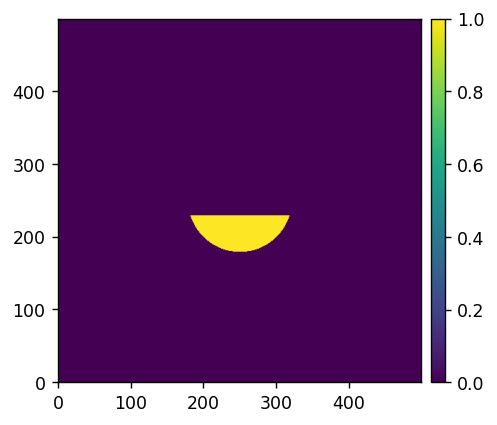

1


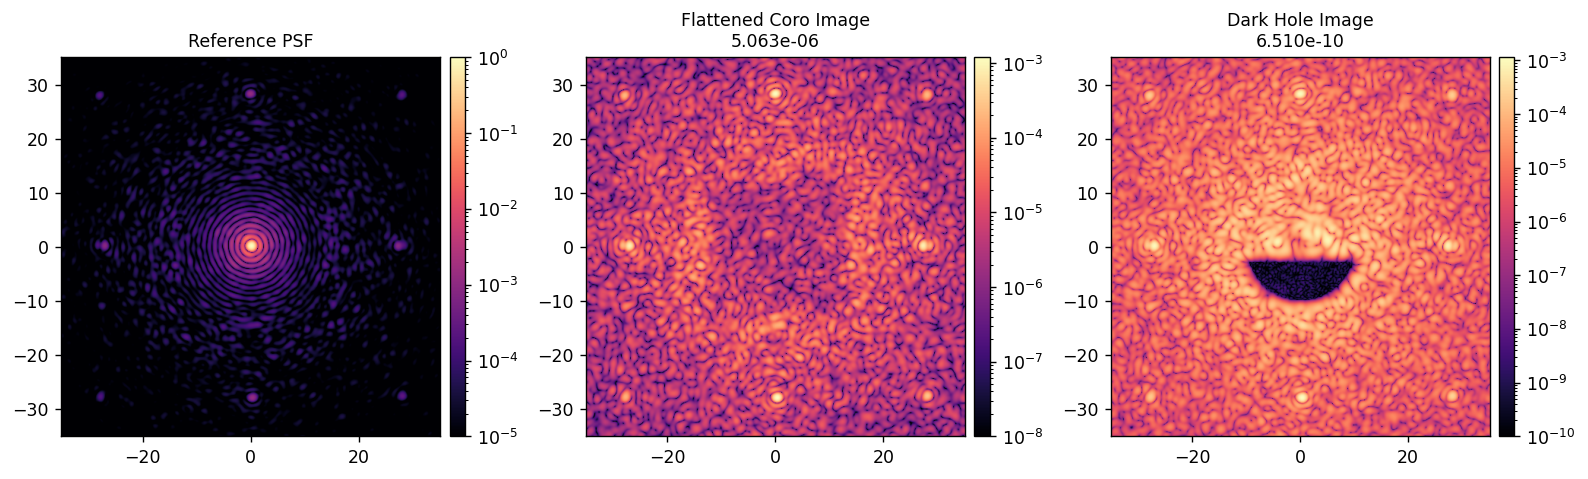

In [4]:
reload(esc)
reload(esc_optics)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 500

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
coro_im_flat = M.snap()

M.set_dm(dh_command, channel=2)
coro_im_dh = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow([coro_mask])

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_flat, coro_im_dh],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Flattened Coro Image\n{contrast_flat:.3e}', 
            f'Dark Hole Image\n{contrast_dh:.3e}'],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

In [5]:
reload(esc)

import ray
ray_esc = ray.remote(esc.single)

N_waves = 5
bw = 0.05
wavelength_c = 650*u.nm
waves = np.linspace(wavelength_c*(1 - bw/2), wavelength_c*(1 + bw/2), N_waves)
print(waves)

[633.75  641.875 650.    658.125 666.25 ] nm


In [6]:
ACTORS = []
for i in range(N_waves):
    params = {
        'wavelength':waves[i],
        # 'npix':1000,
        # 'oversample':4.096,
    }
    ACTORS.append(ray_esc.options(num_cpus=4, num_gpus=1).remote(**params))

2025-04-01 14:20:33,542	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


(pid=376590) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
(pid=376590)   cupy._util.experimental('cupyx.jit.rawkernel')
(single pid=376590) Oversampling > 2x suggested for reliable results in Fresnel propagation.
(pid=376595) /home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future. [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=376595)   cupy._util.experimental('cupyx.jit.rawkernel') [repeated 4x across cluster]


In [7]:
reload(esc)
M = esc.parallel(ACTORS)
M.setattr('wfes', wfes)

1


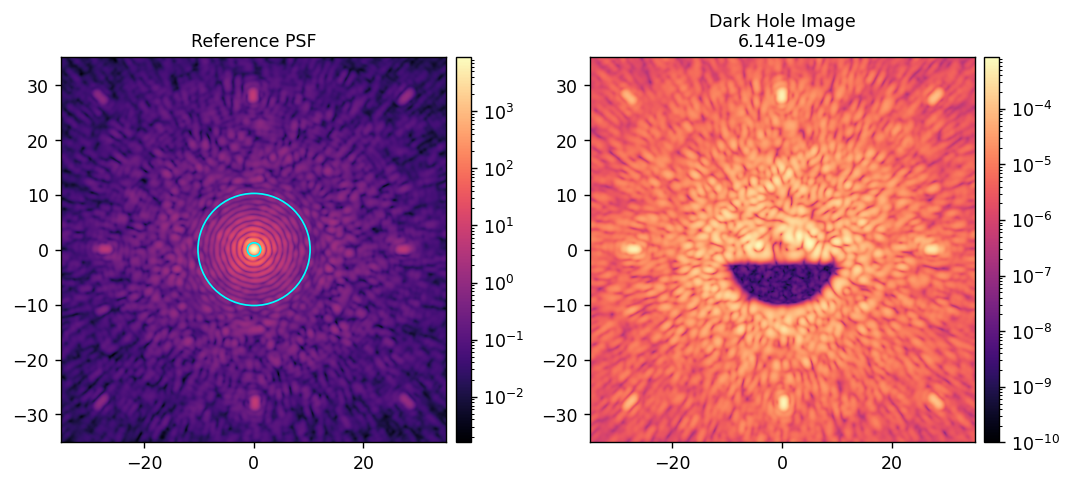

In [9]:
M.setattr('npsf', 500)
M.set_dm(dm_flat)
M.setattr('Imax_ref', 1)
M.setattr('use_vortex', False)
ref_psf = M.snap()
# M.Imax_ref = xp.max(ref_psf)
M.setattr('Imax_ref', xp.max(ref_psf))

M.set_dm(dm_flat + dh_command)
M.setattr('use_vortex', True)
coro_im = M.snap()

bb_contrast = utils.mean(coro_im, coro_mask)

psf_center = (M.camsci_pxscl_lamDc/2, M.camsci_pxscl_lamDc/2)
imshow(
    [ref_psf/M.Imax_ref, coro_im], 
    titles=[f'Reference PSF', 
            f'Dark Hole Image\n{bb_contrast:.3e}'],
    cmaps=['magma']*2,
    norms=[LogNorm(), LogNorm(1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*2,
    all_patches=[ [Circle(psf_center, 1.22, fill=False, color='cyan'), Circle(psf_center, 10.22, fill=False, color='cyan')] ],
)

In [16]:
%timeit M.snap()

385 ms ± 8.55 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
